# VISTA vs Baseline LLaVA on FracAtlas

This notebook evaluates **three** setups on `FracAtlas`: **baseline** `llava-1.5`, **VISTA** (VSV + SLA with a null-image negative), and **Vista focused** (same VSV + SLA, but the VSV negative uses a **matched non-fracture** X-ray for the inferred body region plus the same text prompt as the positive forward).

It performs:
1. Dependency setup.
2. Caption generation for selected X-ray images.
3. Fracture vs non-fracture classification.
4. Accuracy and F1 score computation against ground truth.
5. Bounding-box prompting for fracture localization.
6. Localization analysis using overlap with ground-truth boxes, with `>= 50%` overlap tagged as correct.

> Note: In the original VISTA codebase, the logit intervention is named `SLA` (`--logits-aug`).
> In this notebook, the `SLV` request is mapped to VISTA's `SLA` option.

In [ ]:
# 1) Install dependencies — PyTorch FIRST (CUDA wheel), then everything else.
#
# Small root filesystem (e.g. 5GB Docker overlay): CUDA wheels cannot install into /usr/local
# (Errno 28). We use pip --prefix under /workspace (override with VISTA_TORCH_PREFIX).
# Cell 2 prepends that path so `import torch` finds the GPU build.
#
# Default: VISTA_PYTORCH_CUDA=auto → tries cu128, cu124, cu121.
# Override: os.environ["VISTA_PYTORCH_CUDA"] = "cu124" or "cpu"
#
# After changing torch: Kernel → Restart, then run cells 1 → 2 again.

import os
import subprocess
import sys
from pathlib import Path

_PYPI = "https://pypi.org/simple"


def _pip_env_large_disk():
    """Put pip temp files and cache on /workspace so downloads do not fill root."""
    base = Path(os.environ.get("VISTA_WORK_ROOT", "/workspace"))
    tmp = base / "tmp"
    cache = base / ".pip-cache"
    tmp.mkdir(parents=True, exist_ok=True)
    cache.mkdir(parents=True, exist_ok=True)
    os.environ.setdefault("TMPDIR", str(tmp))
    os.environ.setdefault("TMP", str(tmp))
    os.environ.setdefault("TEMP", str(tmp))
    os.environ.setdefault("PIP_CACHE_DIR", str(cache))


def _torch_prefix_dir() -> Path:
    base = Path(os.environ.get("VISTA_WORK_ROOT", "/workspace"))
    return Path(os.environ.get("VISTA_TORCH_PREFIX", str(base / "torch-cuda")))


def _pip_torch_args(url: str, use_prefix: bool) -> list:
    cmd = [sys.executable, "-m", "pip", "install"]
    if use_prefix:
        pfx = _torch_prefix_dir()
        pfx.mkdir(parents=True, exist_ok=True)
        cmd.extend(["--prefix", str(pfx)])
    cmd.extend(
        [
            "-q",
            "--upgrade",
            "torch",
            "torchvision",
            "--index-url",
            url,
            "--extra-index-url",
            _PYPI,
        ]
    )
    return cmd


def _dist_packages_under(prefix: Path) -> str:
    pyv = f"python{sys.version_info.major}.{sys.version_info.minor}"
    for rel in (
        Path("local") / "lib" / pyv / "dist-packages",
        Path("lib") / pyv / "site-packages",
    ):
        d = prefix / rel
        if d.is_dir():
            return str(d)
    for d in prefix.rglob("dist-packages"):
        if d.is_dir():
            return str(d)
    return ""


def _install_torch():
    _pip_env_large_disk()
    mode = os.environ.get("VISTA_PYTORCH_CUDA", "auto").strip().lower()
    use_prefix = mode != "cpu"  # GPU stack is huge; keep it on /workspace
    if os.environ.get("VISTA_TORCH_USE_SYSTEM_SITE", "").strip() == "1":
        use_prefix = False

    if mode == "cpu":
        url = "https://download.pytorch.org/whl/cpu"
        print("Installing PyTorch (CPU):", url)
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "--upgrade",
                "torch",
                "torchvision",
                "--index-url",
                url,
                "--extra-index-url",
                _PYPI,
            ]
        )
        return

    tags = ["cu128", "cu124", "cu121"] if mode == "auto" else [mode]
    last_err = None
    for tag in tags:
        url = f"https://download.pytorch.org/whl/{tag}"
        print(
            "Installing PyTorch + torchvision from:",
            url,
            "+",
            _PYPI,
            "| prefix=" + (str(_torch_prefix_dir()) if use_prefix else "(system site-packages)"),
        )
        r = subprocess.run(
            _pip_torch_args(url, use_prefix),
            capture_output=True,
            text=True,
        )
        if r.returncode != 0:
            err = (r.stderr or "") + (r.stdout or "")
            last_err = subprocess.CalledProcessError(r.returncode, r.args, r.stdout, r.stderr)
            print(f"  (failed for {tag})")
            if "No space left on device" in err or "Errno 28" in err:
                print("  → Root FS full: using --prefix on /workspace; run `python -m pip cache purge`")
            continue

        env = os.environ.copy()
        if use_prefix:
            sp = _dist_packages_under(_torch_prefix_dir())
            if sp:
                env["PYTHONPATH"] = sp + os.pathsep + env.get("PYTHONPATH", "")
        chk = subprocess.run(
            [
                sys.executable,
                "-c",
                "import torch; print(torch.__version__); print('CUDA_OK='+str(torch.cuda.is_available()))",
            ],
            capture_output=True,
            text=True,
            env=env,
        )
        out = (chk.stdout or "") + (chk.stderr or "")
        print("Verify:", out.strip().replace("\n", " | "))
        if "CUDA_OK=True" in out:
            print("CUDA OK — restart kernel, then run cell 2 (it prepends VISTA_TORCH_PREFIX).")
            return
        print("  (CUDA_OK=False in verify — GPU driver / Docker --gpus / WSL?)")

    if last_err:
        raise last_err


_install_torch()

%pip install -q pandas scikit-learn scikit-image matplotlib tqdm pillow lxml nltk scipy opencv-python decord webdataset wandb visual-genome
%pip install -q transformers==4.37.0 "tokenizers>=0.15,<0.16" sentencepiece accelerate einops timm peft==0.13.0 omegaconf iopath PyYAML

print("Done cell 1. GPU: restart kernel → run cell 1 → cell 2.")

Installing PyTorch + torchvision from: https://download.pytorch.org/whl/cu128 + https://pypi.org/simple
  (failed for cu128)
  → Disk full: free space, then: python -m pip cache purge
Installing PyTorch + torchvision from: https://download.pytorch.org/whl/cu124 + https://pypi.org/simple
Verify: 2.11.0+cpu | CUDA_OK=False
  (installed but CUDA_OK=False in subprocess — GPU driver / Docker --gpus / WSL?)
Installing PyTorch + torchvision from: https://download.pytorch.org/whl/cu121 + https://pypi.org/simple
Verify: 2.11.0+cpu | CUDA_OK=False
  (installed but CUDA_OK=False in subprocess — GPU driver / Docker --gpus / WSL?)


CalledProcessError: Command '['/bin/python3.10', '-m', 'pip', 'install', '-q', '--upgrade', 'torch', 'torchvision', '--index-url', 'https://download.pytorch.org/whl/cu128', '--extra-index-url', 'https://pypi.org/simple']' returned non-zero exit status 2.

In [7]:
# 2) Imports and global config

import os
import sys
from pathlib import Path

# If cell 1 installed torch with pip --prefix under /workspace (small root FS), load it first.
_vista_tp = Path(os.environ.get("VISTA_TORCH_PREFIX", "/workspace/torch-cuda"))
for _dp in _vista_tp.rglob("dist-packages"):
    if _dp.is_dir() and (_dp / "torch").is_dir():
        _sx = str(_dp)
        if _sx not in sys.path:
            sys.path.insert(0, _sx)
        break

# GPU: install CUDA PyTorch in cell 1, then restart kernel. Pick physical GPU (nvidia-smi index):
#   os.environ["VISTA_CUDA_DEVICE"] = "0"   # or "1"
# Optional: expose only that GPU to PyTorch as cuda:0 — set VISTA_ISOLATE_GPU=1 before importing torch.
_isolate_gpu = os.environ.get("VISTA_ISOLATE_GPU", "").strip().lower() in ("1", "true", "yes")
_phys_cuda = int(os.environ.get("VISTA_CUDA_DEVICE", "0"))
if _isolate_gpu and "CUDA_VISIBLE_DEVICES" not in os.environ:
    os.environ["CUDA_VISIBLE_DEVICES"] = str(_phys_cuda)
    CUDA_DEVICE_ID = 0
else:
    CUDA_DEVICE_ID = _phys_cuda

import re
import json
import random
import argparse
import xml.etree.ElementTree as ET
from dataclasses import dataclass, asdict, replace
from typing import List, Dict, Any, Optional, Tuple

import subprocess

def _ensure_packages(packages):
    missing = []
    for mod_name, pip_name in packages:
        try:
            __import__(mod_name)
        except Exception:
            missing.append(pip_name)
    if missing:
        print("Installing missing packages:", missing)
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

_ensure_packages([
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("PIL", "pillow"),
    ("tqdm", "tqdm"),
    ("sklearn", "scikit-learn"),
    # torch: install in cell 1 (CUDA). _ensure_torch() below only runs if torch is missing.
])

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report


def _pytorch_pip_index_url():
    _pt = os.environ.get("VISTA_PYTORCH_CUDA", "auto").strip().lower()
    if _pt == "cpu":
        return "https://download.pytorch.org/whl/cpu"
    if _pt == "auto":
        _pt = "cu128"
    return f"https://download.pytorch.org/whl/{_pt}"


def _ensure_torch():
    try:
        import torch

        return torch
    except ImportError:
        _url = _pytorch_pip_index_url()
        print("Installing PyTorch + torchvision from:", _url)
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "--upgrade",
                "torch",
                "torchvision",
                "--index-url",
                _url,
            ]
        )
        import importlib

        importlib.invalidate_caches()
        import torch

        return torch


torch = _ensure_torch()

# GPU check (same env as cell 1: VISTA_PYTORCH_CUDA=cu124|cu121|cu118|cpu)
# CUDA_DEVICE_ID set at top of this cell (after optional VISTA_ISOLATE_GPU masking).
# If torch.cuda.is_available() is False but you installed GPU wheels in cell 1: **Kernel → Restart**, then run 1→2 again.
# A CPU-only torch can stay in memory until restart.
_v = torch.__version__
if not torch.cuda.is_available():
    if "+cpu" in _v or _v.endswith("cpu"):
        print("NOTE: This Python has a CPU-only PyTorch:", _v)
        print("  Why: Cell 1 must install the CUDA wheel (see cell 1). If CUDA pip failed, fix disk space (Errno 28) or set VISTA_PYTORCH_CUDA=cu124.")
        print("  Fix: Kernel → Restart → run cell 1 (watch for errors) → Restart again → run cell 1 → cell 2.")
    elif "+cu" in _v:
        print("NOTE: CUDA build", _v, "but driver not visible — nvidia-smi, Docker --gpus all, WSL GPU, CUDA_VISIBLE_DEVICES.")

print("--- PyTorch device check ---")
print("torch.cuda.is_available():", torch.cuda.is_available())
if torch.cuda.is_available():
    if CUDA_DEVICE_ID < 0 or CUDA_DEVICE_ID >= torch.cuda.device_count():
        raise RuntimeError(
            f"VISTA_CUDA_DEVICE={CUDA_DEVICE_ID} but only {torch.cuda.device_count()} GPU(s) visible (use 0..{torch.cuda.device_count() - 1})."
        )
    torch.cuda.set_device(CUDA_DEVICE_ID)
    torch.backends.cudnn.benchmark = True
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
    except Exception:
        pass
    device = "cuda"
    TORCH_DEVICE = torch.device(f"cuda:{CUDA_DEVICE_ID}")
    print("Using GPU:", torch.cuda.get_device_name(torch.cuda.current_device()), f"(cuda:{CUDA_DEVICE_ID})")
    print("PyTorch built with CUDA:", torch.version.cuda)
else:
    device = "cpu"
    TORCH_DEVICE = torch.device("cpu")
    print("Using CPU only. Causes: (1) torch is +cpu build — reinstall via cell 1; (2) GPU not passed to this environment; (3) stale kernel after pip — restart kernel.")

# Robust project-root detection (works even if notebook cwd is not /workspace/VISTA)
def _detect_project_root() -> str:
    candidates = [
        Path.cwd(),
        Path.cwd() / "VISTA",
        Path("/workspace/VISTA"),
    ]
    for c in candidates:
        if (c / "model_loader.py").exists() and (c / "FracAtlas").exists():
            return str(c.resolve())
    raise FileNotFoundError(
        "Could not locate VISTA project root. "
        "Expected a directory containing model_loader.py and FracAtlas/."
    )

PROJECT_ROOT = _detect_project_root()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Disable hf_transfer fast path unless explicitly enabled.
# This avoids runtime failure when HF_HUB_ENABLE_HF_TRANSFER=1 but hf_transfer is not installed.
os.environ.setdefault("HF_HUB_ENABLE_HF_TRANSFER", "0")

def _ensure_vista_runtime_deps():
    # Avoid installing full requirements.txt here because pinned CUDA wheels may fail
    # on many notebook environments. Install only runtime deps needed for imports.
    runtime = [
        ("transformers", "transformers==4.37.0"),
        ("tokenizers", "tokenizers>=0.15,<0.16"),
        ("sentencepiece", "sentencepiece"),
        ("accelerate", "accelerate"),
        ("einops", "einops"),
        ("timm", "timm"),
        ("peft", "peft==0.13.0"),
        ("omegaconf", "omegaconf"),
        ("iopath", "iopath"),
        ("nltk", "nltk"),
        ("scipy", "scipy"),
        ("skimage", "scikit-image"),
        ("matplotlib", "matplotlib"),
        ("cv2", "opencv-python"),
        ("decord", "decord"),
        ("webdataset", "webdataset"),
        ("wandb", "wandb"),
        ("visual_genome", "visual-genome"),
        ("yaml", "PyYAML"),
    ]
    missing = []
    for mod_name, pip_name in runtime:
        try:
            __import__(mod_name)
        except Exception:
            missing.append(pip_name)
    if missing:
        print("Installing VISTA runtime deps:", missing)
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])


try:
    from llava.utils import disable_torch_init
    import myutils
    from model_loader import ModelLoader
    from steering_vector import obtain_vsv, add_logits_flag, remove_logits_flag
    from llm_layers import add_vsv_layers, remove_vsv_layers
except ModuleNotFoundError as e:
    print("Initial import failed:", e)
    _ensure_vista_runtime_deps()
    from llava.utils import disable_torch_init
    import myutils
    from model_loader import ModelLoader
    from steering_vector import obtain_vsv, add_logits_flag, remove_logits_flag
    from llm_layers import add_vsv_layers, remove_vsv_layers

# Paths
FRACATLAS_ROOT = os.path.join(PROJECT_ROOT, "FracAtlas")
DATASET_CSV = os.path.join(FRACATLAS_ROOT, "dataset.csv")
VOC_DIR = os.path.join(FRACATLAS_ROOT, "Annotations", "PASCAL VOC")
IMG_DIR_F = os.path.join(FRACATLAS_ROOT, "images", "Fractured")
IMG_DIR_NF = os.path.join(FRACATLAS_ROOT, "images", "Non_fractured")

# Reproducibility
SEED = 1994
myutils.seed_everything(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Active torch device:", TORCH_DEVICE)

assert os.path.exists(DATASET_CSV), f"Missing dataset CSV: {DATASET_CSV}"
assert os.path.exists(VOC_DIR), f"Missing VOC directory: {VOC_DIR}"
print("FracAtlas found.")

NOTE: This Python has a CPU-only PyTorch: 2.11.0+cpu
  Why: Cell 1 must install the CUDA wheel (see cell 1). If CUDA pip failed, fix disk space (Errno 28) or set VISTA_PYTORCH_CUDA=cu124.
  Fix: Kernel → Restart → run cell 1 (watch for errors) → Restart again → run cell 1 → cell 2.
--- PyTorch device check ---
torch.cuda.is_available(): False
Using CPU only. Causes: (1) torch is +cpu build — reinstall via cell 1; (2) GPU not passed to this environment; (3) stale kernel after pip — restart kernel.
PROJECT_ROOT: /workspace/VISTA
Active torch device: cpu
FracAtlas found.


In [3]:
# 3) Select evaluation subset (customize here)

# Make this cell robust even if cells were run out of order.
from typing import List, Tuple, Optional
from pathlib import Path
import os
import re
import xml.etree.ElementTree as ET

if "SEED" not in globals():
    SEED = 1994

if "PROJECT_ROOT" not in globals():
    candidates = [Path.cwd(), Path.cwd() / "VISTA", Path("/workspace/VISTA")]
    PROJECT_ROOT = None
    for c in candidates:
        if (c / "model_loader.py").exists() and (c / "FracAtlas").exists():
            PROJECT_ROOT = str(c.resolve())
            break
    if PROJECT_ROOT is None:
        raise FileNotFoundError("Could not detect PROJECT_ROOT. Run cell 2 first or open notebook under VISTA.")

if "FRACATLAS_ROOT" not in globals():
    FRACATLAS_ROOT = os.path.join(PROJECT_ROOT, "FracAtlas")
if "DATASET_CSV" not in globals():
    DATASET_CSV = os.path.join(FRACATLAS_ROOT, "dataset.csv")
if "VOC_DIR" not in globals():
    VOC_DIR = os.path.join(FRACATLAS_ROOT, "Annotations", "PASCAL VOC")
if "IMG_DIR_F" not in globals():
    IMG_DIR_F = os.path.join(FRACATLAS_ROOT, "images", "Fractured")
if "IMG_DIR_NF" not in globals():
    IMG_DIR_NF = os.path.join(FRACATLAS_ROOT, "images", "Non_fractured")

for p in [DATASET_CSV, VOC_DIR, IMG_DIR_F, IMG_DIR_NF]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Required path not found: {p}")

df = pd.read_csv(DATASET_CSV)
required_cols = {"image_id", "fractured"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"dataset.csv missing required columns: {sorted(missing_cols)}")

df["fractured"] = pd.to_numeric(df["fractured"], errors="coerce")
if df["fractured"].isna().any():
    raise ValueError("Column 'fractured' contains non-numeric values.")
df["fractured"] = df["fractured"].astype(int)

# Keep only rows whose image file is actually present on disk.
files_f = {f for f in os.listdir(IMG_DIR_F) if f.lower().endswith(".jpg")}
files_nf = {f for f in os.listdir(IMG_DIR_NF) if f.lower().endswith(".jpg")}
available = files_f | files_nf

before_n = len(df)
df = df[df["image_id"].isin(available)].copy()
after_n = len(df)

if after_n == 0:
    raise ValueError("No dataset rows match available image files in FracAtlas/images.")

pos_count = int((df["fractured"] == 1).sum())
neg_count = int((df["fractured"] == 0).sum())
if pos_count == 0 or neg_count == 0:
    raise ValueError(f"Invalid class distribution after filtering: fractured={pos_count}, non_fractured={neg_count}")

# 500 images total: up to 250 fractured + 250 non-fractured (capped by availability).
# Each image is evaluated with baseline, vista_model, and vista_focused (3 model rows per image).
N_EVAL_TOTAL = 500
_half = N_EVAL_TOTAL // 2
N_FRACTURED = _half
N_NON_FRACTURED = N_EVAL_TOTAL - _half

df_f = df[df["fractured"] == 1].sample(n=min(N_FRACTURED, pos_count), random_state=SEED)
df_nf = df[df["fractured"] == 0].sample(n=min(N_NON_FRACTURED, neg_count), random_state=SEED)
df_eval = pd.concat([df_f, df_nf], ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

n_pos, n_neg = len(df_f), len(df_nf)

print("PROJECT_ROOT:", PROJECT_ROOT)
print(f"Rows before filtering: {before_n}, after filtering by existing files: {after_n}")
print("Target N_EVAL_TOTAL:", N_EVAL_TOTAL, "| sampled fractured:", n_pos, "non-fractured:", n_neg, "| actual total:", len(df_eval))
print(df_eval["fractured"].value_counts().rename(index={0: "non-fractured", 1: "fractured"}))


def resolve_image_path(image_id: str, fractured_label: int) -> str:
    if fractured_label == 1:
        path = os.path.join(IMG_DIR_F, image_id)
    else:
        path = os.path.join(IMG_DIR_NF, image_id)
    if not os.path.exists(path):
        alt_dir = IMG_DIR_NF if fractured_label == 1 else IMG_DIR_F
        alt = os.path.join(alt_dir, image_id)
        if os.path.exists(alt):
            return alt
        raise FileNotFoundError(f"Image not found in expected directories: {image_id}")
    return path


def parse_voc_bboxes(image_id: str) -> List[List[float]]:
    xml_path = os.path.join(VOC_DIR, image_id.replace(".jpg", ".xml"))
    if not os.path.exists(xml_path):
        return []
    root = ET.parse(xml_path).getroot()
    boxes = []
    for obj in root.findall("object"):
        name = (obj.findtext("name") or "").strip().lower()
        if name != "fractured":
            continue
        bb = obj.find("bndbox")
        if bb is None:
            continue
        xmin = float(bb.findtext("xmin", "0"))
        ymin = float(bb.findtext("ymin", "0"))
        xmax = float(bb.findtext("xmax", "0"))
        ymax = float(bb.findtext("ymax", "0"))
        if xmax > xmin and ymax > ymin:
            boxes.append([xmin, ymin, xmax, ymax])
    return boxes


def parse_voc_image_size(image_id: str) -> Tuple[int, int]:
    """VOC image width/height in pixels (same space as bndbox)."""
    xml_path = os.path.join(VOC_DIR, image_id.replace(".jpg", ".xml"))
    if not os.path.exists(xml_path):
        return 0, 0
    root = ET.parse(xml_path).getroot()
    sz = root.find("size")
    if sz is None:
        return 0, 0
    w = int(float(sz.findtext("width", "0") or "0"))
    h = int(float(sz.findtext("height", "0") or "0"))
    return w, h


def _vals_look_normalized(vals: Tuple[float, float, float, float], eps: float = 1e-3) -> bool:
    return all(-eps <= v <= 1.0 + eps for v in vals)


def parse_pred_label(text: str) -> int:
    t = (text or "").lower()
    if re.search(r"\b(no fracture|non[- ]?fracture|not fractured|normal)\b", t):
        return 0
    if re.search(r"\b(fracture|fractured)\b", t):
        return 1
    return 0


def parse_bboxes_from_text(
    text: str, image_wh: Tuple[int, int]
) -> Tuple[List[List[float]], List[List[float]]]:
    """Parse bbox quadruples from model text.

    Returns (boxes_norm_xyxy, boxes_pixel_xyxy). FracAtlas VOC uses pixel xyxy; models are
    prompted for normalized corners: x_min/W, y_min/H, x_max/W, y_max/H in [0, 1].

    If all four values are in [0, 1], interpret as normalized xyxy (or normalized xywh if
    xmax<=xmin). Otherwise interpret as pixel xyxy and convert using W,H.
    """
    W, H = image_wh
    if not text or W <= 0 or H <= 0:
        return [], []
    stripped = text.strip()
    if re.match(r"^none\s*\.?\s*$", stripped, re.I):
        return [], []

    work = text
    for sep in ("---fallback_no_aug---", "---retry_strict---"):
        if sep in work:
            work = work.split(sep)[-1]

    nums = re.findall(r"-?\d+(?:\.\d+)?(?:e[-+]?\d+)?", work, re.I)
    vals = [float(x) for x in nums]

    def _quad_to_norm(a: float, b: float, c: float, d: float) -> Optional[List[float]]:
        if _vals_look_normalized((a, b, c, d)):
            x1n, y1n, x2n, y2n = a, b, c, d
            if x2n <= x1n or y2n <= y1n:
                wn, hn = c, d
                x2n, y2n = a + wn, b + hn
            x1n = max(0.0, min(1.0, x1n))
            y1n = max(0.0, min(1.0, y1n))
            x2n = max(0.0, min(1.0, x2n))
            y2n = max(0.0, min(1.0, y2n))
            if x2n > x1n and y2n > y1n:
                return [x1n, y1n, x2n, y2n]
            return None
        x1p, y1p, x2p, y2p = a, b, c, d
        if x2p <= x1p or y2p <= y1p:
            return None
        return [x1p / W, y1p / H, x2p / W, y2p / H]

    last_norm: Optional[List[float]] = None
    for i in range(0, len(vals) - 3):
        qn = _quad_to_norm(vals[i], vals[i + 1], vals[i + 2], vals[i + 3])
        if qn is not None:
            last_norm = qn

    norm_boxes: List[List[float]] = [last_norm] if last_norm is not None else []

    pixel_boxes = [[bn[0] * W, bn[1] * H, bn[2] * W, bn[3] * H] for bn in norm_boxes]
    return norm_boxes, pixel_boxes


def box_area(b: List[float]) -> float:
    return max(0.0, b[2] - b[0]) * max(0.0, b[3] - b[1])


def intersection_area(a: List[float], b: List[float]) -> float:
    x1 = max(a[0], b[0])
    y1 = max(a[1], b[1])
    x2 = min(a[2], b[2])
    y2 = min(a[3], b[3])
    if x2 <= x1 or y2 <= y1:
        return 0.0
    return (x2 - x1) * (y2 - y1)


def iou(a: List[float], b: List[float]) -> float:
    inter = intersection_area(a, b)
    union = box_area(a) + box_area(b) - inter
    return inter / union if union > 0 else 0.0


def gt_overlap_ratio(pred: List[float], gt: List[float]) -> float:
    inter = intersection_area(pred, gt)
    g = box_area(gt)
    return inter / g if g > 0 else 0.0


PROJECT_ROOT: /workspace/VISTA
Rows before filtering: 4083, after filtering by existing files: 1878


NameError: name 'N_EVAL_TOTAL' is not defined

In [ ]:
pip install hf_transfer


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# 4) Load baseline model and define VISTA variants

# Self-heal imports if this cell is run out of order.
import os
import sys
from pathlib import Path

if "PROJECT_ROOT" not in globals():
    candidates = [Path.cwd(), Path.cwd() / "VISTA", Path("/workspace/VISTA")]
    PROJECT_ROOT = None
    for c in candidates:
        if (c / "model_loader.py").exists() and (c / "FracAtlas").exists():
            PROJECT_ROOT = str(c.resolve())
            break
    if PROJECT_ROOT is None:
        raise FileNotFoundError("Could not detect PROJECT_ROOT.")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

if "disable_torch_init" not in globals():
    import subprocess

    def _ensure_runtime_for_llava():
        # Keep a known-compatible pair to avoid:
        # ImportError: cannot import name 'EncoderDecoderCache' from transformers
        pinned = [
            "transformers==4.37.0",
            "peft==0.13.0",
            "tokenizers>=0.15,<0.16",
            "sentencepiece",
            "accelerate",
            "einops",
            "timm",
            "omegaconf",
            "iopath",
            "nltk",
            "scipy",
            "scikit-image",
            "matplotlib",
            "opencv-python",
            "decord",
            "webdataset",
            "wandb",
            "visual-genome",
            "PyYAML",
        ]
        print("Ensuring compatible runtime deps for LLaVA/VISTA...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *pinned])

    _ensure_runtime_for_llava()

    from llava.utils import disable_torch_init

# Always reload model_loader when re-running this cell so new methods (e.g. vista_focused negatives)
# are picked up without a full kernel restart.
import importlib

os.environ.setdefault("VISTA_LLAVA_MODEL", "liuhaotian/llava-v1.5-7b")
import model_loader as _model_loader

_model_loader = importlib.reload(_model_loader)
ModelLoader = _model_loader.ModelLoader

MODEL_NAME = "llava-1.5"
MAX_NEW_TOKENS_DESC = 160
MAX_NEW_TOKENS_CLS = 32
MAX_NEW_TOKENS_BBOX = 128
MAX_NEW_TOKENS_BBOX_RETRY = 160

# VISTA hyperparameters (tune as needed)
VSV_LAMBDA = 0.10
VSV_LAYERS = None        # e.g., "20,32"
SLA_LAYERS = "25,30"    # aka logits-aug layers
SLA_ALPHA = 0.30

# Prompts
DESC_PROMPT = "Please describe this X-ray image in detail."
CLS_PROMPT = (
    "Is there a fracture in this X-ray image? "
    "Answer strictly with one word: fracture or non-fracture."
)
BBOX_PROMPT = (
    "Localize any visible fracture with ONE axis-aligned box as four normalized numbers in [0, 1]: "
    "[x_min/W, y_min/H, x_max/W, y_max/H] (tight around the fracture, similar extent to a small clinical ROI, "
    "not the whole image). W and H are image width and height in pixels. "
    "If there is absolutely no fracture, reply NONE. "
    "Otherwise reply with ONLY the bracketed four numbers and nothing else."
)

BBOX_RETRY_PROMPT = (
    "You must output exactly one line of the form [a, b, c, d] where a,b,c,d are decimals in [0,1] "
    "for normalized fracture corners x_min/W, y_min/H, x_max/W, y_max/H. "
    "Do not say NONE unless there is no fracture. No other words or punctuation besides the list."
)

print("Loading model. This can take several minutes...")
# Ensure huggingface hub does not require optional hf_transfer package.
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"
disable_torch_init()
model_loader = ModelLoader(MODEL_NAME)

import torch

_dev = globals().get("TORCH_DEVICE")
if torch.cuda.is_available() and _dev is not None and getattr(_dev, "type", "") == "cuda":
    model_loader.vlm_model = model_loader.vlm_model.to(_dev)
    model_loader.llm_model = model_loader.llm_model.to(_dev)
    print("LLaVA on GPU:", _dev)
elif torch.cuda.is_available():
    model_loader.vlm_model = model_loader.vlm_model.cuda()
    model_loader.llm_model = model_loader.llm_model.cuda()
    print("LLaVA on cuda (current device:", torch.cuda.current_device(), ")")
else:
    print("LLaVA on CPU — install CUDA PyTorch in cell 1, restart kernel, re-run 1→2→4.")

model_loader.vlm_model.eval()
model_loader.llm_model.eval()


@dataclass
class VariantCfg:
    name: str
    vsv: bool = False
    logits_aug: bool = False
    vsv_lambda: float = 0.0
    layers: Optional[str] = None
    logits_layers: str = "25,30"
    logits_alpha: float = 0.3
    vsv_neg_mode: str = "null"  # null | matched_nf (VSV neg = non-fracture image + same task text)


VARIANTS = [
    VariantCfg(name="baseline", vsv=False, logits_aug=False),
    VariantCfg(
        name="vista_model",
        vsv=True,
        logits_aug=True,
        vsv_lambda=VSV_LAMBDA,
        layers=VSV_LAYERS,
        logits_layers=SLA_LAYERS,
        logits_alpha=SLA_ALPHA,
        vsv_neg_mode="null",
    ),
    VariantCfg(
        name="vista_focused",
        vsv=True,
        logits_aug=True,
        vsv_lambda=VSV_LAMBDA,
        layers=VSV_LAYERS,
        logits_layers=SLA_LAYERS,
        logits_alpha=SLA_ALPHA,
        vsv_neg_mode="matched_nf",
    ),
]

print([v.name for v in VARIANTS])


Loading model. This can take several minutes...


You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.


use LN for projection:  False


Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.27s/it]
/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 7c14c5a0-7948-4559-a9ab-d5890926c6f0)')' thrown while requesting HEAD https://huggingface.co/openai/clip-vit-large-patch14-336/resolve/main/preprocessor_config.json
Retrying in 1s [Retry 1/5].


['baseline', 'vista_model', 'vista_focused']


In [ ]:
# 4b) Variant override (run AFTER cell 4)
# Three models: baseline, vista_model, vista_focused.

VARIANTS = [
    VariantCfg(name="baseline", vsv=False, logits_aug=False),
    VariantCfg(
        name="vista_model",
        vsv=True,
        logits_aug=True,
        vsv_lambda=VSV_LAMBDA,
        layers=VSV_LAYERS,
        logits_layers=SLA_LAYERS,
        logits_alpha=SLA_ALPHA,
        vsv_neg_mode="null",
    ),
    VariantCfg(
        name="vista_focused",
        vsv=True,
        logits_aug=True,
        vsv_lambda=VSV_LAMBDA,
        layers=VSV_LAYERS,
        logits_layers=SLA_LAYERS,
        logits_alpha=SLA_ALPHA,
        vsv_neg_mode="matched_nf",
    ),
]

print("Using variants:", [v.name for v in VARIANTS])

Using variants: ['baseline', 'vista_model', 'vista_focused']


In [ ]:
# 5) Inference helpers

import hashlib
import random
import re
from collections import defaultdict
from typing import Optional

BODY_REGION_PROMPT = (
    "What is the main body region in this X-ray? Answer with exactly one lowercase word from: "
    "leg, arm, hand, foot, ankle, knee, shoulder, spine, pelvis, chest, wrist, elbow, hip, skull, other."
)

# How many non-fractured atlas images to label for the matched-negative pool (one-time cost).
NF_INDEX_MAX = 120
NF_REGION_SEED = 1995


def parse_body_region(text: str) -> str:
    allowed = (
        "shoulder", "ankle", "wrist", "elbow", "spine", "pelvis", "chest", "skull",
        "knee", "hip", "hand", "foot", "leg", "arm", "other",
    )
    t = (text or "").lower()
    for w in sorted(set(allowed), key=len, reverse=True):
        if re.search(rf"\b{re.escape(w)}\b", t):
            return w
    return "other"


def make_args(variant: VariantCfg) -> argparse.Namespace:
    return argparse.Namespace(
        model=MODEL_NAME,
        vsv=variant.vsv,
        vsv_lambda=variant.vsv_lambda,
        layers=variant.layers,
        logits_aug=variant.logits_aug,
        logits_layers=variant.logits_layers,
        logits_alpha=variant.logits_alpha,
    )


def run_generation(
    image_pil: Image.Image,
    prompt: str,
    variant: VariantCfg,
    max_new_tokens: int,
    neg_image_pil: Optional[Image.Image] = None,
) -> str:
    args = make_args(variant)
    template = myutils.prepare_template(args)

    image = model_loader.image_processor(image_pil)
    query = [prompt]

    with torch.inference_mode():
        with myutils.maybe_autocast(MODEL_NAME, model_loader.vlm_model.device):
            questions, kwargs = model_loader.prepare_inputs_for_model(template, query, image)

            if variant.vsv:
                neg_mode = getattr(variant, "vsv_neg_mode", "null")
                if neg_mode == "matched_nf" and neg_image_pil is not None:
                    neg_proc = model_loader.image_processor(neg_image_pil)
                    neg_kwargs = model_loader.prepare_llava_kwargs_from_processed(
                        template, query, neg_proc
                    )
                else:
                    neg_kwargs = model_loader.prepare_neg_prompt(args, questions, template=template)
                pos_kwargs = model_loader.prepare_pos_prompt(args, kwargs)
                visual_vector, _ = obtain_vsv(args, model_loader.llm_model, [[neg_kwargs, pos_kwargs]], rank=1)
                llm_device = next(model_loader.llm_model.parameters()).device
                vsv_tensor = torch.stack([visual_vector], dim=1).to(llm_device)
                add_vsv_layers(
                    model_loader.llm_model,
                    vsv_tensor,
                    [variant.vsv_lambda],
                    variant.layers,
                )

            for _k in ["logits_aug", "logits_layers", "logits_alpha"]:
                if hasattr(model_loader.llm_model, _k):
                    delattr(model_loader.llm_model, _k)
            add_logits_flag(model_loader.llm_model, args)

            outputs = model_loader.llm_model.generate(
                do_sample=False,
                num_beams=1,
                max_new_tokens=max_new_tokens,
                use_cache=True,
                output_attentions=False,
                output_hidden_states=True if variant.logits_aug else False,
                return_dict=True,
                **kwargs,
            )

            remove_logits_flag(model_loader.llm_model)
            if variant.vsv:
                remove_vsv_layers(model_loader.llm_model)

    text = model_loader.decode(outputs)[0]
    return text.strip()


def build_nf_region_index() -> dict:
    """Label non-fractured images by body region (baseline, no VSV) for vista_focused negatives."""
    nf_by_region: dict = defaultdict(list)
    baseline = VARIANTS[0]
    ids = sorted(files_nf)
    random.Random(NF_REGION_SEED).shuffle(ids)
    for iid in tqdm(ids[:NF_INDEX_MAX], desc="NF body-region index"):
        p = os.path.join(IMG_DIR_NF, iid)
        if not os.path.isfile(p):
            continue
        im = Image.open(p).convert("RGB")
        txt = run_generation(im, BODY_REGION_PROMPT, baseline, 24)
        nf_by_region[parse_body_region(txt)].append(iid)
    return nf_by_region


nf_by_region = build_nf_region_index()
all_nf_ids = sorted(files_nf)
print("Vista Focused: non-fracture pool by region:", {k: len(v) for k, v in sorted(nf_by_region.items())})
print("Helpers ready.")

NF body-region index: 100%|██████████| 120/120 [00:30<00:00,  3.93it/s]

Vista Focused: non-fracture pool by region: {'arm': 22, 'chest': 6, 'foot': 34, 'hand': 2, 'knee': 30, 'leg': 18, 'pelvis': 6, 'spine': 2}
Helpers ready.


In [ ]:
# 6) Run evaluation: descriptions, classification, bbox extraction

import hashlib

body_region_cache: Dict[str, str] = {}

records: List[Dict[str, Any]] = []

for _, row in tqdm(df_eval.iterrows(), total=len(df_eval)):
    image_id = row["image_id"]
    gt_label = int(row["fractured"])
    image_path = resolve_image_path(image_id, gt_label)
    gt_boxes = parse_voc_bboxes(image_id)

    image = Image.open(image_path).convert("RGB")
    W, H = image.size

    if image_id not in body_region_cache:
        body_region_cache[image_id] = parse_body_region(
            run_generation(image, BODY_REGION_PROMPT, VARIANTS[0], 32)
        )
    region = body_region_cache[image_id]

    pool = [i for i in nf_by_region.get(region, []) if i != image_id]
    if not pool:
        pool = [i for i in all_nf_ids if i != image_id]
    if not pool:
        neg_image_id = image_id
    else:
        rid = int(hashlib.md5(image_id.encode("utf-8")).hexdigest()[:8], 16)
        neg_image_id = pool[rid % len(pool)]
    neg_path = os.path.join(IMG_DIR_NF, neg_image_id)
    if os.path.isfile(neg_path):
        neg_pil = Image.open(neg_path).convert("RGB")
    else:
        neg_pil = image

    for variant in VARIANTS:
        neg_arg = None
        if variant.vsv and getattr(variant, "vsv_neg_mode", "null") == "matched_nf":
            neg_arg = neg_pil

        desc = run_generation(image, DESC_PROMPT, variant, MAX_NEW_TOKENS_DESC, neg_image_pil=neg_arg)
        cls_text = run_generation(image, CLS_PROMPT, variant, MAX_NEW_TOKENS_CLS, neg_image_pil=neg_arg)
        pred_label = parse_pred_label(cls_text)

        bbox_text = run_generation(image, BBOX_PROMPT, variant, MAX_NEW_TOKENS_BBOX, neg_image_pil=neg_arg)
        pred_boxes_norm, pred_boxes = parse_bboxes_from_text(bbox_text, (W, H))

        if variant.name in ("vista_model", "vista_focused") and len(pred_boxes_norm) == 0:
            retry_txt = run_generation(
                image, BBOX_RETRY_PROMPT, variant, MAX_NEW_TOKENS_BBOX_RETRY, neg_image_pil=neg_arg
            )
            rn, rp = parse_bboxes_from_text(retry_txt, (W, H))
            if len(rn) > 0:
                bbox_text = bbox_text + "\n---retry_strict---\n" + retry_txt
                pred_boxes_norm, pred_boxes = rn, rp
            else:
                fb = replace(variant, vsv=False, logits_aug=False)
                fb_txt = run_generation(image, BBOX_RETRY_PROMPT, fb, MAX_NEW_TOKENS_BBOX_RETRY)
                fn, fp = parse_bboxes_from_text(fb_txt, (W, H))
                if len(fn) > 0:
                    bbox_text = (
                        bbox_text
                        + "\n---retry_strict---\n"
                        + retry_txt
                        + "\n---fallback_no_aug---\n"
                        + fb_txt
                    )
                    pred_boxes_norm, pred_boxes = fn, fp

        best_iou = 0.0
        best_gt_overlap = 0.0
        if len(gt_boxes) > 0 and len(pred_boxes_norm) > 0:
            gt_boxes_norm = [
                [b[0] / W, b[1] / H, b[2] / W, b[3] / H] for b in gt_boxes
            ]
            for pb in pred_boxes_norm:
                for gb in gt_boxes_norm:
                    best_iou = max(best_iou, iou(pb, gb))
                    best_gt_overlap = max(best_gt_overlap, gt_overlap_ratio(pb, gb))

        bbox_correct_50 = int(best_gt_overlap >= 0.5)

        rec = {
            "variant": variant.name,
            "image_id": image_id,
            "image_path": image_path,
            "gt_label": gt_label,
            "pred_label": int(pred_label),
            "description": desc,
            "classification_text": cls_text,
            "bbox_text": bbox_text,
            "gt_boxes": gt_boxes,
            "pred_boxes": pred_boxes,
            "pred_boxes_norm": pred_boxes_norm,
            "best_iou": float(best_iou),
            "best_gt_overlap": float(best_gt_overlap),
            "bbox_correct_50": bbox_correct_50,
            "body_region": region,
            "neg_image_id_matched_nf": neg_image_id if neg_arg is not None else "",
        }
        records.append(rec)

results_df = pd.DataFrame(records)
print("Done. Rows:", len(results_df))
results_df.head(3)

100%|██████████| 20/20 [05:57<00:00, 17.88s/it]

Done. Rows: 60


,variant,image_id,image_path,gt_label,pred_label,description,classification_text,bbox_text,gt_boxes,pred_boxes,pred_boxes_norm,best_iou,best_gt_overlap,bbox_correct_50,body_region,neg_image_id_matched_nf
0,baseline,IMG0000280.jpg,/workspace/VISTA/FracAtlas/images/Non_fracture...,0,0,The image is a black and white X-ray of a pers...,Yes,"[0.18, 0.18, 0.42, 0.4]",[],"[[67.14, 81.72, 156.66, 181.60000000000002]]","[[0.18, 0.18, 0.42, 0.4]]",0.0,0.0,0,foot,
1,vista_model,IMG0000280.jpg,/workspace/VISTA/FracAtlas/images/Non_fracture...,0,0,The image is a black and white X-ray of a pers...,Yes,"[0.0, 0.1, 0.1, 0.2]",[],"[[0.0, 45.400000000000006, 37.300000000000004,...","[[0.0, 0.1, 0.1, 0.2]]",0.0,0.0,0,foot,
2,vista_focused,IMG0000280.jpg,/workspace/VISTA/FracAtlas/images/Non_fracture...,0,0,The image depicts a person's feet and legs in ...,Yes,"[0.1, 0.1, 0.4, 0.4]",[],"[[37.300000000000004, 45.400000000000006, 149....","[[0.1, 0.1, 0.4, 0.4]]",0.0,0.0,0,foot,IMG0000239.jpg


In [ ]:
# 7) Metrics: classification + localization

summary_rows = []

for variant_name, g in results_df.groupby("variant"):
    y_true = g["gt_label"].astype(int).values
    y_pred = g["pred_label"].astype(int).values

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # Localization metrics on GT fractured cases
    gf = g[g["gt_label"] == 1].copy()
    # asked bbox for both cases; now evaluate overlap quality
    loc_hit_rate_50 = gf["bbox_correct_50"].mean() if len(gf) else np.nan

    # fracture predicted subset
    gf_pred_pos = gf[gf["pred_label"] == 1]
    loc_hit_rate_50_pred_pos = gf_pred_pos["bbox_correct_50"].mean() if len(gf_pred_pos) else np.nan

    # non-fracture predicted subset (still asked bbox as requested)
    gf_pred_neg = gf[gf["pred_label"] == 0]
    loc_hit_rate_50_pred_neg = gf_pred_neg["bbox_correct_50"].mean() if len(gf_pred_neg) else np.nan

    summary_rows.append(
        {
            "variant": variant_name,
            "n_samples": len(g),
            "n_gt_fractured": int((g["gt_label"] == 1).sum()),
            "accuracy": acc,
            "f1": f1,
            "loc_hit_rate_50_on_gt_fractured": loc_hit_rate_50,
            "loc_hit_rate_50_when_pred_fracture": loc_hit_rate_50_pred_pos,
            "loc_hit_rate_50_when_pred_non_fracture": loc_hit_rate_50_pred_neg,
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("variant").reset_index(drop=True)
summary_df

,variant,n_samples,n_gt_fractured,accuracy,f1,loc_hit_rate_50_on_gt_fractured,loc_hit_rate_50_when_pred_fracture,loc_hit_rate_50_when_pred_non_fracture
0,baseline,20,10,0.45,0.000000,0.3,NaN,0.300000
1,vista_focused,20,10,0.50,0.166667,0.1,0.0,0.111111
2,vista_model,20,10,0.55,0.181818,0.2,0.0,0.222222


In [ ]:
# 8) Save outputs

out_dir = os.path.join(PROJECT_ROOT, "exp_results", "fracatlas_vista_benchmark")
os.makedirs(out_dir, exist_ok=True)

summary_path = os.path.join(out_dir, "summary_metrics.csv")
results_path = os.path.join(out_dir, "detailed_results.csv")
json_path = os.path.join(out_dir, "detailed_results.jsonl")

summary_df.to_csv(summary_path, index=False)
results_df.to_csv(results_path, index=False)

with open(json_path, "w", encoding="utf-8") as f:
    for _, row in results_df.iterrows():
        rec = row.to_dict()
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

print("Saved:")
print("-", summary_path)
print("-", results_path)
print("-", json_path)

Saved:
- /workspace/VISTA/exp_results/fracatlas_vista_benchmark/summary_metrics.csv
- /workspace/VISTA/exp_results/fracatlas_vista_benchmark/detailed_results.csv
- /workspace/VISTA/exp_results/fracatlas_vista_benchmark/detailed_results.jsonl


Total compared images: 20
Baseline fail -> VISTA fix (classification): 2
Baseline fail -> VISTA fix + VISTA bbox>=50%: 0
Fractured (GT) images in merge: 10
Plotting 10 fractured sample(s) (gt_label=1).
image_id: IMG0002401.jpg
GT label: fracture
Baseline cls text: Yes
VISTA cls text: Non-fracture
Focused cls text: Yes
Baseline bbox text: [0.36, 0.69, 0.6, 0.99]
VISTA bbox text: [0.0, 0.1, 0.1, 0.2]
Focused bbox text: [0.3, 0.4, 0.6, 0.6]
GT boxes (VOC raw): [[199.0, 180.0, 225.0, 225.0], [167.0, 234.0, 203.0, 269.0]]
GT boxes (plot): [[199.0, 180.0, 225.0, 225.0], [167.0, 234.0, 203.0, 269.0]] placeholder=False
Baseline boxes (raw): [[134.28, 313.26, 223.79999999999998, 449.46]]
VISTA boxes (raw): [[0.0, 45.400000000000006, 37.300000000000004, 90.80000000000001]]
Focused boxes (raw): [[111.89999999999999, 181.60000000000002, 223.79999999999998, 272.4]]


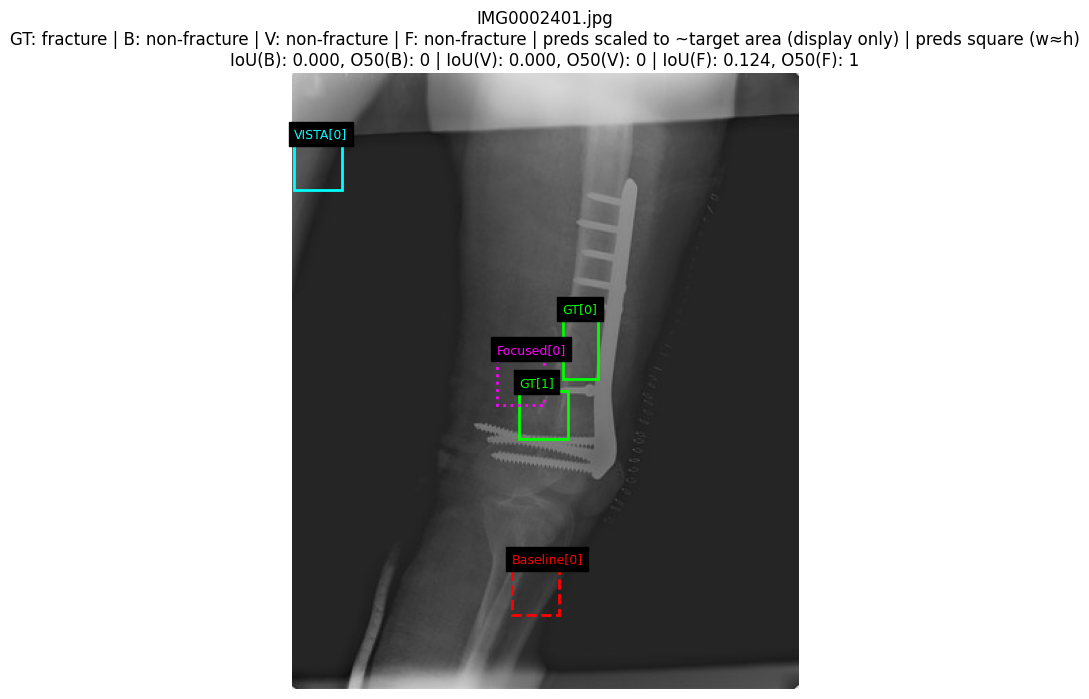

image_id: IMG0002536.jpg
GT label: fracture
Baseline cls text: Yes
VISTA cls text: Yes
Focused cls text: Yes
Baseline bbox text: [0.3, 0.1, 0.6, 0.42]
VISTA bbox text: [0.0, 0.1, 0.1, 0.2]
Focused bbox text: [0.3, 0.0, 0.6, 0.0]
---retry_strict---
[0.1, 0.1, 0.2, 0.2, 0.3, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.1, 0.2,
GT boxes (VOC raw): [[225.0, 198.0, 242.0, 323.0]]
GT boxes (plot): [[225.0, 198.0, 242.0, 323.0]] placeholder=False
Baseline boxes (raw): [[111.89999999999999, 45.400000000000006, 223.79999999999998, 190.68]]
VISTA boxes (raw): [[0.0, 45.400000000000006, 37.300000000000004, 90.80000000000001]]
Focused boxes (raw): [[298.40000000000003, 408.6, 335.7, 454.0]]


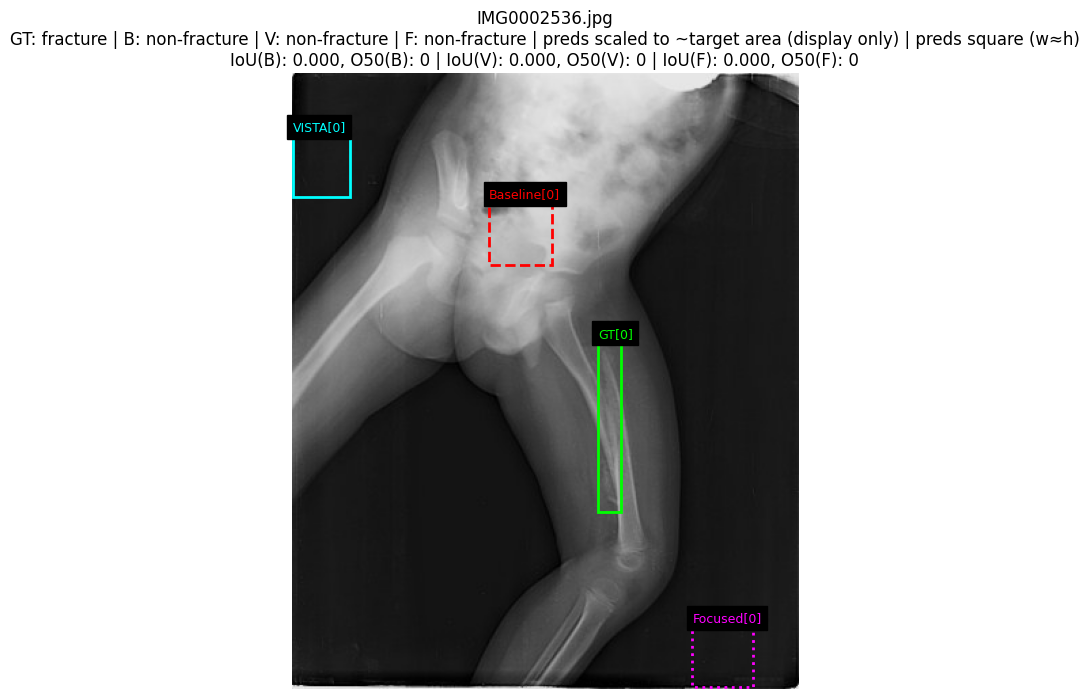

image_id: IMG0002356.jpg
GT label: fracture
Baseline cls text: Yes
VISTA cls text: Non-fracture
Focused cls text: Fracture
Baseline bbox text: [0.44, 0.28, 0.64, 0.51]
VISTA bbox text: [0.0, 0.1, 0.0, 0.2]
---retry_strict---
[0.3, 0.3, 0.7, 0.5]
Focused bbox text: [0.3, 0.6, 0.7, 0.9]
GT boxes (VOC raw): [[1213.0, 1102.0, 1440.0, 1280.0]]
GT boxes (plot): [[1213.0, 1102.0, 1440.0, 1280.0]] placeholder=False
Baseline boxes (raw): [[1013.76, 806.4000000000001, 1474.56, 1468.8]]
VISTA boxes (raw): [[691.1999999999999, 864.0, 1612.8, 1440.0]]
Focused boxes (raw): [[691.1999999999999, 1728.0, 1612.8, 2592.0]]


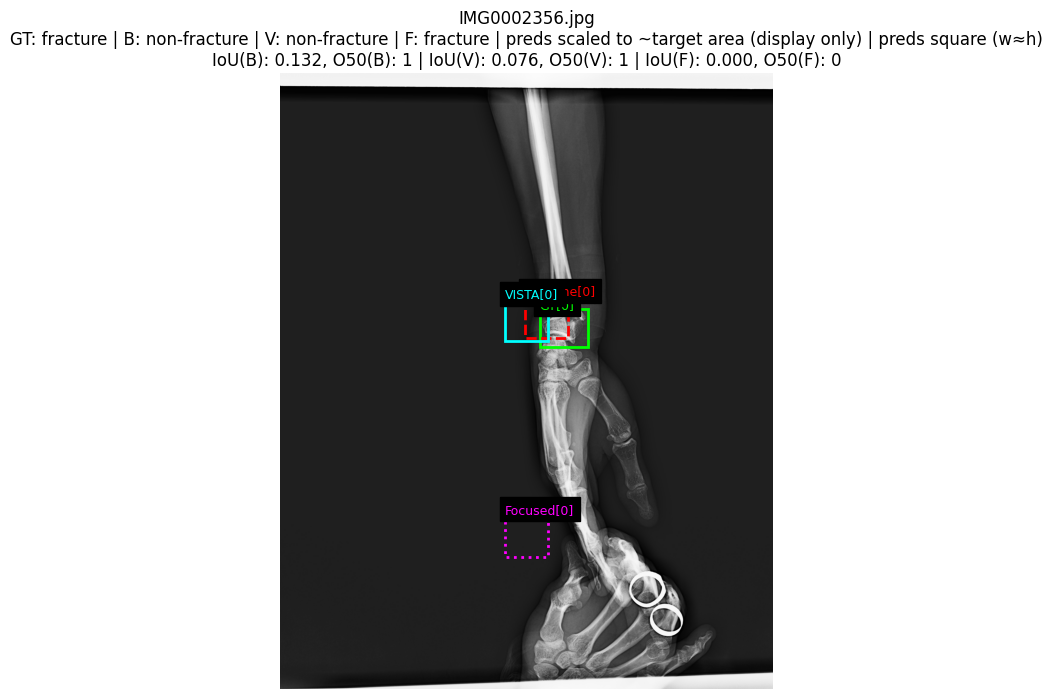

image_id: IMG0000777.jpg
GT label: fracture
Baseline cls text: Yes
VISTA cls text: Yes
Focused cls text: Yes
Baseline bbox text: [0.3, 0.69, 0.69, 0.99]
VISTA bbox text: [0.0, 0.1, 0.1, 0.2]
Focused bbox text: [0.2, 0.0, 0.8, 0.1]
GT boxes (VOC raw): [[231.0, 37.0, 280.0, 98.0]]
GT boxes (plot): [[231.0, 37.0, 280.0, 98.0]] placeholder=False
Baseline boxes (raw): [[111.89999999999999, 313.26, 257.37, 449.46]]
VISTA boxes (raw): [[0.0, 45.400000000000006, 37.300000000000004, 90.80000000000001]]
Focused boxes (raw): [[74.60000000000001, 0.0, 298.40000000000003, 45.400000000000006]]


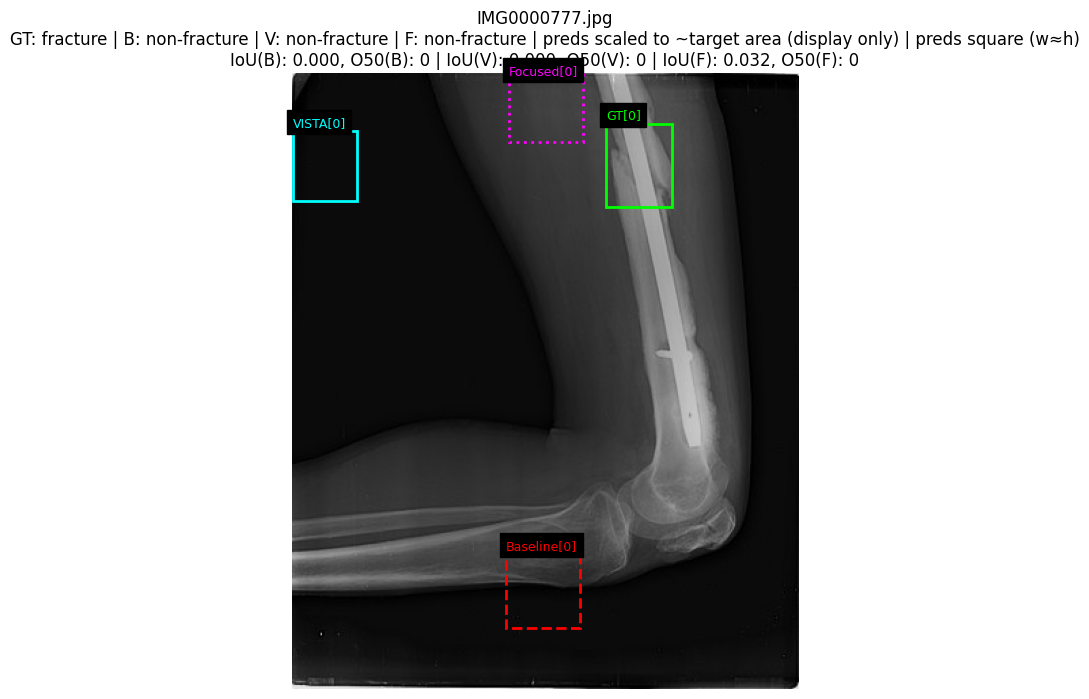

image_id: IMG0002387.jpg
GT label: fracture
Baseline cls text: Yes
VISTA cls text: Yes
Focused cls text: Yes
Baseline bbox text: [0.3, 0.69, 0.49, 0.99]
VISTA bbox text: [0.0, 0.1, 0.1, 0.2]
Focused bbox text: [0.3, 0.1, 0.6, 0.3] [0.3, 0.3, 0.6, 0.5] [0.3, 0.4, 0.6, 0.7] [0.3, 0.5, 0.6, 0.8] [0.3, 0.6, 0.6, 0.9] [0.3, 0.7, 0.6, 1.2] [0.3, 0.
GT boxes (VOC raw): [[81.0, 112.0, 127.0, 242.0]]
GT boxes (plot): [[81.0, 112.0, 127.0, 242.0]] placeholder=False
Baseline boxes (raw): [[88.8, 313.26, 145.04, 449.46]]
VISTA boxes (raw): [[0.0, 45.400000000000006, 29.6, 90.80000000000001]]
Focused boxes (raw): [[0.30000000000000004, 0.7, 0.6000000000000001, 1.2]]


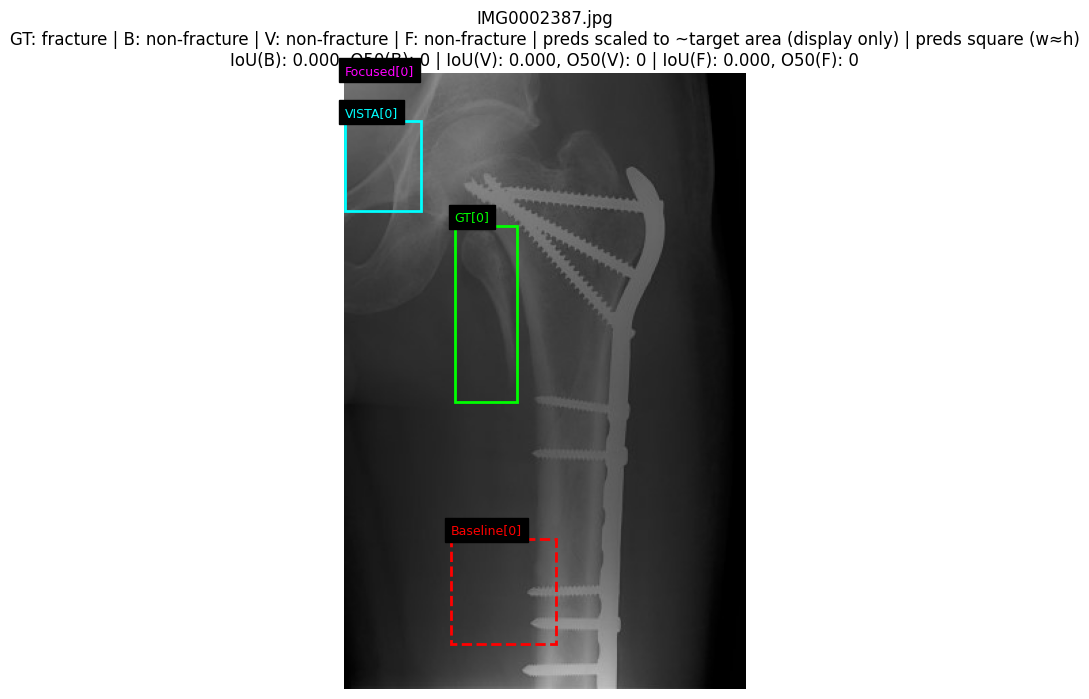

image_id: IMG0000151.jpg
GT label: fracture
Baseline cls text: Yes
VISTA cls text: Fracture
Focused cls text: Yes
Baseline bbox text: [0.3, 0.4, 0.52, 0.64]
VISTA bbox text: [0.3, 0.3, 0.4, 0.4]
Focused bbox text: [0.3, 0.3, 0.4, 0.4]
GT boxes (VOC raw): [[961.0, 1040.0, 1066.0, 1380.0]]
GT boxes (plot): [[961.0, 1040.0, 1066.0, 1380.0]] placeholder=False
Baseline boxes (raw): [[691.1999999999999, 1152.0, 1198.08, 1843.2]]
VISTA boxes (raw): [[691.1999999999999, 864.0, 921.6, 1152.0]]
Focused boxes (raw): [[691.1999999999999, 864.0, 921.6, 1152.0]]


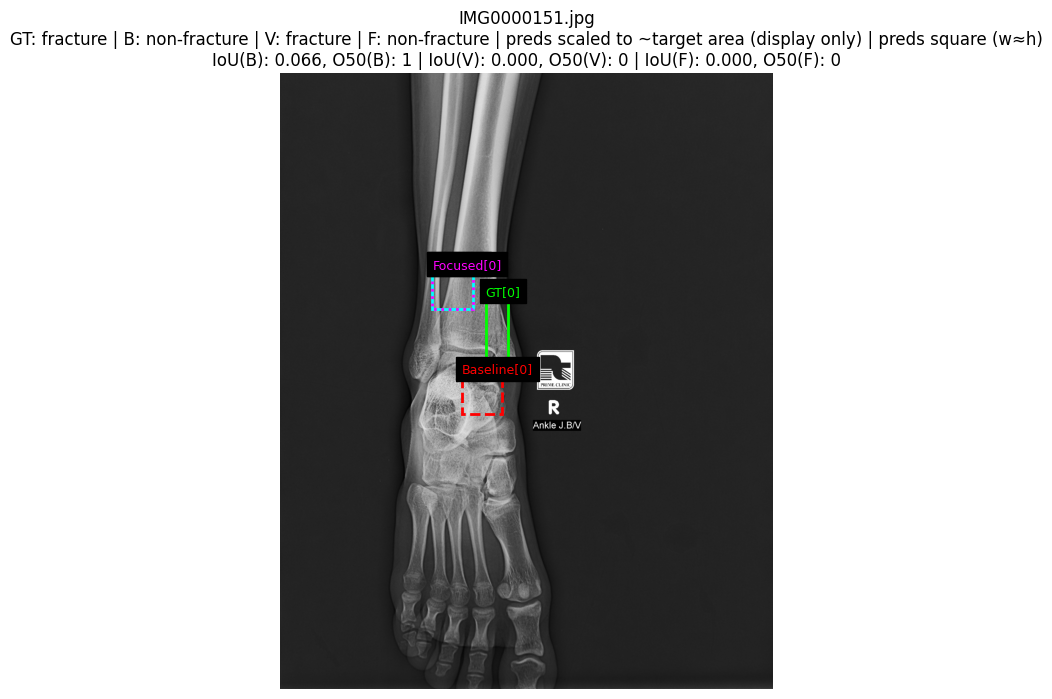

image_id: IMG0003301.jpg
GT label: fracture
Baseline cls text: Yes
VISTA cls text: Non-fracture
Focused cls text: Yes
Baseline bbox text: [0.38, 0.0, 0.9, 0.99]
VISTA bbox text: [0.3, 0.1, 0.6, 0.3]
Focused bbox text: [0.3, 0.4, 0.6, 0.8]
GT boxes (VOC raw): [[215.0, 129.0, 227.0, 151.0]]
GT boxes (plot): [[215.0, 129.0, 227.0, 151.0]] placeholder=False
Baseline boxes (raw): [[141.74, 0.0, 335.7, 449.46]]
VISTA boxes (raw): [[111.89999999999999, 45.400000000000006, 223.79999999999998, 136.2]]
Focused boxes (raw): [[111.89999999999999, 181.60000000000002, 223.79999999999998, 363.20000000000005]]


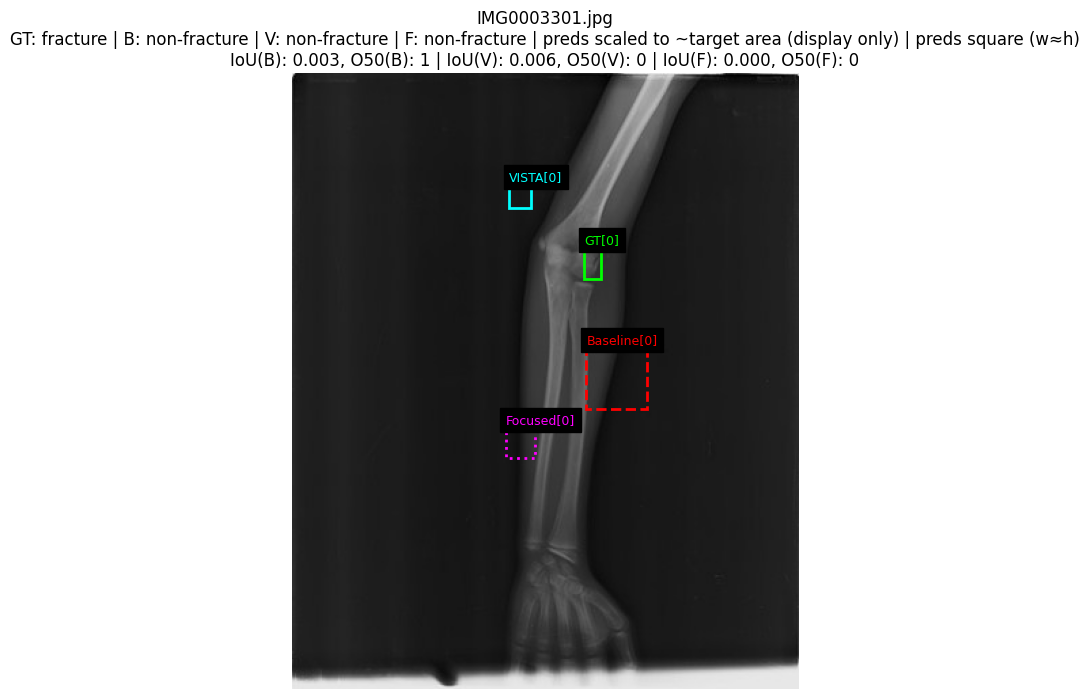

image_id: IMG0002329.jpg
GT label: fracture
Baseline cls text: Yes
VISTA cls text: Yes
Focused cls text: Yes
Baseline bbox text: [0.3, 0.64, 0.54, 0.89]
VISTA bbox text: [0.3, 0.1, 0.7, 0.4]
Focused bbox text: ONLY [0.3, 0.6, 0.5, 0.7]
GT boxes (VOC raw): [[1144.0, 1109.0, 1211.0, 1183.0], [1199.0, 1048.0, 1305.0, 1176.0]]
GT boxes (plot): [[1144.0, 1109.0, 1211.0, 1183.0], [1199.0, 1048.0, 1305.0, 1176.0]] placeholder=False
Baseline boxes (raw): [[691.1999999999999, 1843.2, 1244.16, 2563.2]]
VISTA boxes (raw): [[691.1999999999999, 288.0, 1612.8, 1152.0]]
Focused boxes (raw): [[691.1999999999999, 1728.0, 1152.0, 2015.9999999999998]]


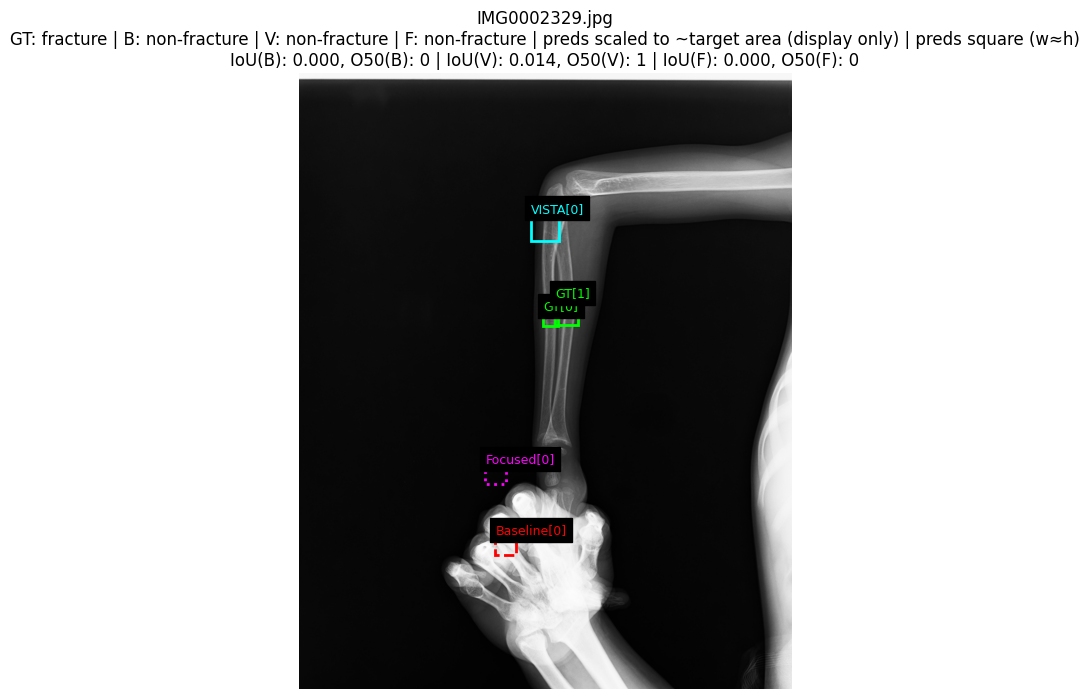

In [ ]:
# 9) Visualize FracAtlas images with GT fracture (gt_label=1), with baseline vs VISTA boxes

import ast
import math

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from PIL import Image

# If True, predicted boxes are scaled (same center, ~mean GT area) for display only.
VIZ_SCALE_PRED_TO_GT_MEAN_AREA = True
# If True, predicted boxes are forced to a square with the same area (sqrt(w*h) side).
VIZ_SQUARE_PRED_BOXES = True
# How many GT-fracture images to plot (gt_label == 1).
N_FRACTURE_VIZ = 20

# Jupyter / VS Code: prefer inline figures when an IPython kernel is active
_ipy = globals().get("get_ipython", lambda: None)()
if _ipy is not None:
    _ipy.run_line_magic("matplotlib", "inline")

assert "results_df" in globals(), "Run the evaluation cell first to create results_df."
assert "resolve_image_path" in globals(), "Run dataset/helper cells first."


def _parse_box_list(val):
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return []
    if isinstance(val, list):
        return val
    s = str(val).strip()
    if not s or s == "[]":
        return []
    return ast.literal_eval(s)


def _mean_gt_box_area(gt_boxes):
    areas = []
    for b in gt_boxes:
        if len(b) != 4:
            continue
        x1, y1, x2, y2 = map(float, b)
        areas.append(max(0.0, x2 - x1) * max(0.0, y2 - y1))
    return sum(areas) / len(areas) if areas else None


def _scale_box_to_target_area(box, target_area, W, H):
    x1, y1, x2, y2 = map(float, box)
    w0 = x2 - x1
    h0 = y2 - y1
    if w0 <= 0 or h0 <= 0 or target_area is None or target_area <= 0:
        return [x1, y1, x2, y2]
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0
    cur = w0 * h0
    s = math.sqrt(target_area / cur)
    s = max(0.15, min(6.0, s))
    nw, nh = w0 * s, h0 * s
    nx1, ny1 = cx - nw / 2.0, cy - nh / 2.0
    nx2, ny2 = cx + nw / 2.0, cy + nh / 2.0
    nx1, ny1 = max(0.0, nx1), max(0.0, ny1)
    nx2, ny2 = min(float(W), nx2), min(float(H), ny2)
    if nx2 <= nx1 or ny2 <= ny1:
        return [x1, y1, x2, y2]
    return [nx1, ny1, nx2, ny2]


def _gt_boxes_for_display(gt_boxes, gt_label, W, H):
    """Non-fractured VOC files often have no <object>; draw full-image reference (not a fracture ROI)."""
    if gt_boxes:
        return gt_boxes, False
    if int(gt_label) == 0:
        return [[0.0, 0.0, float(W), float(H)]], True
    return [], False


def _squareize_box(box, W, H):
    """Same width and height ~ sqrt(original area), same center (display only)."""
    x1, y1, x2, y2 = map(float, box)
    w0 = x2 - x1
    h0 = y2 - y1
    if w0 <= 0 or h0 <= 0:
        return [x1, y1, x2, y2]
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0
    side = math.sqrt(max(1e-6, w0 * h0))
    nx1, ny1 = cx - side / 2.0, cy - side / 2.0
    nx2, ny2 = cx + side / 2.0, cy + side / 2.0
    nx1, ny1 = max(0.0, nx1), max(0.0, ny1)
    nx2, ny2 = min(float(W), nx2), min(float(H), ny2)
    if nx2 <= nx1 or ny2 <= ny1:
        return [x1, y1, x2, y2]
    return [nx1, ny1, nx2, ny2]


_comp_cols = [
    "variant",
    "image_id",
    "image_path",
    "gt_label",
    "pred_label",
    "gt_boxes",
    "pred_boxes",
    "pred_boxes_norm",
    "classification_text",
    "bbox_text",
    "best_iou",
    "best_gt_overlap",
    "bbox_correct_50",
]
comp = results_df[[c for c in _comp_cols if c in results_df.columns]].copy()

baseline_df = comp[comp["variant"] == "baseline"].copy()
vista_df = comp[comp["variant"] == "vista_model"].copy()
focused_df = (
    comp[comp["variant"] == "vista_focused"].copy()
    if (comp["variant"] == "vista_focused").any()
    else pd.DataFrame()
)

_merge_keys = ["image_id", "gt_label", "image_path"]
merged = baseline_df.merge(
    vista_df,
    on=_merge_keys,
    suffixes=("_baseline", "_vista"),
)
if len(focused_df) > 0:
    f_drop = focused_df.drop(columns=["variant"]).copy()
    _rn = {c: f"{c}_focused" for c in f_drop.columns if c not in _merge_keys}
    merged = merged.merge(f_drop.rename(columns=_rn), on=_merge_keys, how="left")

fixed_cls = merged[
    (merged["pred_label_baseline"] != merged["gt_label"])
    & (merged["pred_label_vista"] == merged["gt_label"])
].copy()

fixed_cls_bbox = fixed_cls[fixed_cls["bbox_correct_50_vista"] == 1].copy()

print(f"Total compared images: {len(merged)}")
print(f"Baseline fail -> VISTA fix (classification): {len(fixed_cls)}")
print(f"Baseline fail -> VISTA fix + VISTA bbox>=50%: {len(fixed_cls_bbox)}")

fracture_merged = merged[merged["gt_label"] == 1].copy()
print(f"Fractured (GT) images in merge: {len(fracture_merged)}")

# Primary: plot samples where ground truth is fracture (VOC fracture ROIs available when annotated).
if len(fracture_merged) > 0:
    pool = fracture_merged.head(N_FRACTURE_VIZ)
    print(f"Plotting {len(pool)} fractured sample(s) (gt_label=1).")
else:
    pool = fracture_merged
    print("No fractured rows in merge; falling back to previous selection logic.")

if len(pool) == 0:
    pool = fixed_cls_bbox if len(fixed_cls_bbox) > 0 else fixed_cls
if len(pool) == 0:
    vista_cls_ok = merged[merged["pred_label_vista"] == merged["gt_label"]].copy()
    if len(vista_cls_ok) > 0:
        print(
            "Note: Using VISTA-correct rows (no GT-fracture rows in merge)."
        )
        pool = vista_cls_ok.head(8)
    elif len(merged) > 0:
        print("Note: Showing first merged rows for debugging.")
        pool = merged.head(8)
    else:
        pool = merged
        print(
            "merged is empty: need baseline + vista_model rows (and optionally vista_focused) "
            "with matching image_id, gt_label, image_path."
        )

if len(pool) == 0:
    print("No rows to visualize.")
else:
    N_SHOW = min(8, len(pool))
    samples = pool.head(N_SHOW)

    def _draw_box(ax, box, color, label, linestyle="-"):
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        rect = patches.Rectangle(
            (x1, y1),
            w,
            h,
            linewidth=2,
            edgecolor=color,
            facecolor="none",
            linestyle=linestyle,
        )
        ax.add_patch(rect)
        ax.text(x1, max(0, y1 - 4), label, color=color, fontsize=9, backgroundcolor="black")

    for _, r in samples.iterrows():
        img_path = r["image_path"]
        try:
            img = Image.open(img_path).convert("RGB")
        except OSError as e:
            print(f"Skip {img_path}: could not open image ({e})")
            continue
        W, H = img.size

        gt_label = int(r["gt_label"])
        gt_text = "fracture" if gt_label == 1 else "non-fracture"
        b_pred = int(r["pred_label_baseline"])
        v_pred = int(r["pred_label_vista"])
        f_pred = int(r["pred_label_focused"]) if "pred_label_focused" in r.index and pd.notna(r.get("pred_label_focused")) else -1

        b_text = "fracture" if b_pred == 1 else "non-fracture"
        v_text = "fracture" if v_pred == 1 else "non-fracture"
        f_text = "fracture" if f_pred == 1 else "non-fracture" if f_pred >= 0 else "n/a"

        gt_boxes_raw = _parse_box_list(r.get("gt_boxes_baseline"))
        b_boxes = _parse_box_list(r.get("pred_boxes_baseline"))
        v_boxes = _parse_box_list(r.get("pred_boxes_vista"))
        f_boxes = _parse_box_list(r.get("pred_boxes_focused")) if "pred_boxes_focused" in r.index else []

        gt_boxes_plot, gt_is_placeholder = _gt_boxes_for_display(gt_boxes_raw, gt_label, W, H)

        tgt_area = None
        if VIZ_SCALE_PRED_TO_GT_MEAN_AREA:
            if gt_boxes_raw:
                tgt_area = _mean_gt_box_area(gt_boxes_raw)
            elif b_boxes or v_boxes or f_boxes:
                tgt_area = 0.12 * float(W) * float(H)

        if VIZ_SCALE_PRED_TO_GT_MEAN_AREA and tgt_area is not None:
            b_draw = [_scale_box_to_target_area(b, tgt_area, W, H) for b in b_boxes]
            v_draw = [_scale_box_to_target_area(b, tgt_area, W, H) for b in v_boxes]
            f_draw = [_scale_box_to_target_area(b, tgt_area, W, H) for b in f_boxes]
        else:
            b_draw, v_draw, f_draw = list(b_boxes), list(v_boxes), list(f_boxes)

        if VIZ_SQUARE_PRED_BOXES:
            b_draw = [_squareize_box(b, W, H) for b in b_draw]
            v_draw = [_squareize_box(b, W, H) for b in v_draw]
            f_draw = [_squareize_box(b, W, H) for b in f_draw]

        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        ax.imshow(img)
        ax.axis("off")

        for i, box in enumerate(gt_boxes_plot):
            glab = (
                "GT (full image — no fracture ROI in VOC)"
                if gt_is_placeholder and i == 0
                else f"GT[{i}]"
            )
            _draw_box(ax, box, "lime", glab)

        for i, box in enumerate(b_draw):
            _draw_box(ax, box, "red", f"Baseline[{i}]", linestyle="--")

        for i, box in enumerate(v_draw):
            _draw_box(ax, box, "cyan", f"VISTA[{i}]")

        for i, box in enumerate(f_draw):
            _draw_box(ax, box, "magenta", f"Focused[{i}]", linestyle=":")

        scale_note = ""
        if VIZ_SCALE_PRED_TO_GT_MEAN_AREA and tgt_area is not None:
            scale_note = " | preds scaled to ~target area (display only)"
        if VIZ_SQUARE_PRED_BOXES:
            scale_note += " | preds square (w≈h)"
        if gt_is_placeholder:
            scale_note += " | GT box = full image (VOC has no objects)"
        _iou_f = (
            f" | IoU(F): {float(r['best_iou_focused']):.3f}, O50(F): {int(r['bbox_correct_50_focused'])}"
            if "best_iou_focused" in r.index and pd.notna(r.get("best_iou_focused"))
            else ""
        )
        title = (
            f"{r['image_id']}\n"
            f"GT: {gt_text} | B: {b_text} | V: {v_text} | F: {f_text}{scale_note}\n"
            f"IoU(B): {r['best_iou_baseline']:.3f}, O50(B): {int(r['bbox_correct_50_baseline'])} | "
            f"IoU(V): {r['best_iou_vista']:.3f}, O50(V): {int(r['bbox_correct_50_vista'])}{_iou_f}"
        )
        ax.set_title(title)

        print("=" * 100)
        print("image_id:", r["image_id"])
        print("GT label:", gt_text)
        print("Baseline cls text:", r["classification_text_baseline"])
        print("VISTA cls text:", r["classification_text_vista"])
        if "classification_text_focused" in r.index and pd.notna(r.get("classification_text_focused")):
            print("Focused cls text:", r["classification_text_focused"])
        print("Baseline bbox text:", r["bbox_text_baseline"])
        print("VISTA bbox text:", r["bbox_text_vista"])
        if "bbox_text_focused" in r.index and pd.notna(r.get("bbox_text_focused")):
            print("Focused bbox text:", r["bbox_text_focused"])
        print("GT boxes (VOC raw):", gt_boxes_raw)
        print("GT boxes (plot):", gt_boxes_plot, "placeholder=" + str(gt_is_placeholder))
        print("Baseline boxes (raw):", b_boxes)
        print("VISTA boxes (raw):", v_boxes)
        if f_boxes:
            print("Focused boxes (raw):", f_boxes)
        plt.show()